Problem 1: The Perceptron

⇒ Implement the perceptron algorithm from scratch in Python.

⇒ Train it on a simple dataset (e.g., AND or OR).

a) Plot the decision boundary.

b) Explain why the perceptron fails on XOR.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng=np.random.default_rng(42)
num_points = 400

# 每個座標獨立選擇：0 -> [-0.3, 0.3)，1 -> [0.7, 1.3)
region = rng.integers(0, 2, size=(300, 2))

# 先生成第一段區間 [-0.3, 0.3) 的數值
points = rng.uniform(-0.3, 0.3, size=(300, 2))

# 若 region 對應位置為 1，將該座標改成第二段區間 [0.7, 1.3)
# 這段是 NumPy 的 Boolean indexing（布林遮罩索引）
# 初看不直覺。它的意思是：region == 1 會產生一張 True/False 的「遮罩」
# 再把 points 裡遮罩為 True 的位置，替換成第二段區間的亂數。
points[region == 1] = rng.uniform(
    0.7,
    1.3,
    size=np.sum(region == 1)
)
points_new = rng.uniform(-0.3, 1.3, size=(100, 2))

points = np.concatenate((points, points_new), axis=0)

print(points.shape)
print(points[:5])

(400, 2)
[[ 0.16739781  0.98104998]
 [ 0.8556639   0.00853372]
 [ 0.21454329  0.72710387]
 [-0.0689463   0.9888948 ]
 [-0.14012201 -0.21613895]]


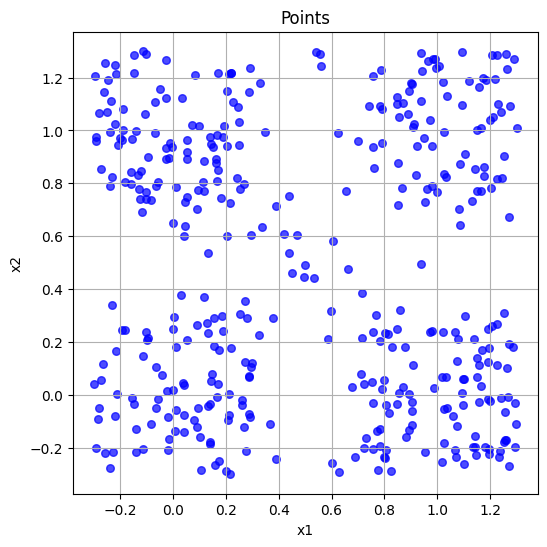

In [ ]:
#type((points[:, 0] + points[:, 1] >= 2).astype(int))


plt.figure(figsize=(6, 6))
plt.scatter(
    points[:, 0], 
    points[:, 1],
    color="blue",
    s=30,
    alpha=0.7
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Points")
plt.grid(True)
plt.axis("equal")  # x、y 軸比例相同，避免圖形被拉寬或壓扁
plt.show()

In [73]:

# 建立標籤：當input >=1 表示邏輯的1 ，否則為邏輯的0
# 也就是 label = 1 若在右上側，否則 label = 0
# 結果為 一維的ndarray，長度為 100 裡面是資料集的答案
#[:,0] 代表取所有列的第0欄，也就是 x1
#[:,1] 代表取所有列的第1欄，也就是 x2
AND_labels = ((points[:, 0] >= 0.5) & (points[:, 1] >= 0.5)).astype(int)
OR_labels = ((points[:, 0] >= 0.5) | (points[:, 1] >= 0.5)).astype(int)
XOR_labels = ((points[:, 0] >= 0.5) & (points[:, 1] < 0.5)) | ((points[:, 0] < 0.5) & (points[:, 1] >= 0.5)).astype(int)

# 將資料整理成 (x, y, label) 的格式
# 若你想要的資料格式可以視為 (x, y) + 對應 label
AND_raw_data = [(float(x), float(y), int(label)) for (x, y), label in zip(points, AND_labels)]
OR_raw_data = [(float(x), float(y), int(label)) for (x, y), label in zip(points, OR_labels)]
XOR_raw_data = [(float(x), float(y), int(label)) for (x, y), label in zip(points, XOR_labels)]


In [83]:
w1 = 0.0
w2 = 0.0
bias = 0.0

w3 = 0.0
w4 = 0.0
bias2 = 0.0

w5 = 0.0
w6 = 0.0
bias3 = 0.0

learning_rate = 0.05
def AND_perceptron_predict(x1, x2):
    linear_output = w1 * x1 + w2 * x2 + bias
    return 1 if linear_output >= 0 else 0
def OR_perceptron_predict(x1, x2):
    linear_output = w3 * x1 + w4 * x2 + bias2
    return 1 if linear_output >= 0 else 0

def XOR_perceptron_predict(x1, x2):
    linear_output = w5 * x1 + w6 * x2 + bias3
    return 1 if linear_output >= 0 else 0
# 訓練 perceptron
#error 表示預測結果與實際標籤的差距，若預測正確則 error = 0，若預測錯誤則 error = ±1
#bias 的更新方式與權重相同，都是根據 error 與學習率進行調整,也就是erro越大調整得越多
#w1和w2的更新方式也是根據 error 與學習率進行調整，並且乘上對應的輸入值 x1 或 x2，這樣可以讓權重朝著正確的方向調整，以減少預測錯誤。
def AND_perceptron_train(X, y, epochs):
    global w1, w2, bias
    for epoch in range(epochs):
        for (x1, x2), label in zip(X, y):
            prediction = AND_perceptron_predict(x1, x2)
            error = label - prediction
            w1 += learning_rate * error * x1
            w2 += learning_rate * error * x2
            bias += learning_rate * error
            
def OR_perceptron_train(X, y, epochs):
    global w3, w4, bias2
    for epoch in range(epochs):
        for (x1, x2), label in zip(X, y):
            prediction = OR_perceptron_predict(x1, x2)
            error = label - prediction
            w3 += learning_rate * error * x1
            w4 += learning_rate * error * x2
            bias2 += learning_rate * error

def XOR_perceptron_train(X, y, epochs):
    global w5, w6, bias3
    for epoch in range(epochs):
        for (x1, x2), label in zip(X, y):
            prediction = XOR_perceptron_predict(x1, x2)
            error = label - prediction
            w5 += learning_rate * error * x1
            w6 += learning_rate * error * x2
            bias3 += learning_rate * error

In [84]:
#perceptron訓練
for x1,x2,y in AND_raw_data:
    if AND_perceptron_predict(x1, x2) != y:
        AND_perceptron_train([(x1, x2)], [y], epochs=1)
for x1,x2,y in OR_raw_data:
    if OR_perceptron_predict(x1, x2) != y:
        OR_perceptron_train([(x1, x2)], [y], epochs=1)
for x1,x2,y in XOR_raw_data:
    if XOR_perceptron_predict(x1,x2) != y:
        XOR_perceptron_train([(x1,x2)], [y], epochs=1)

In [85]:
print(f"Trained weights: w1={w1}, w2={w2}, bias={bias}")
print(f"Trained weights: w3={w3}, w4={w4}, bias2={bias2}")
print(f"Trained weights: w5={w5}, w6={w6}, bias3={bias3}")

Trained weights: w1=0.1632144489256639, w2=0.1386326753779993, bias=-0.25
Trained weights: w3=0.16654332639347902, w4=0.09396731902234097, bias2=-0.05
Trained weights: w5=0.024533434194823702, w6=-0.0627386821524516, bias3=0.0


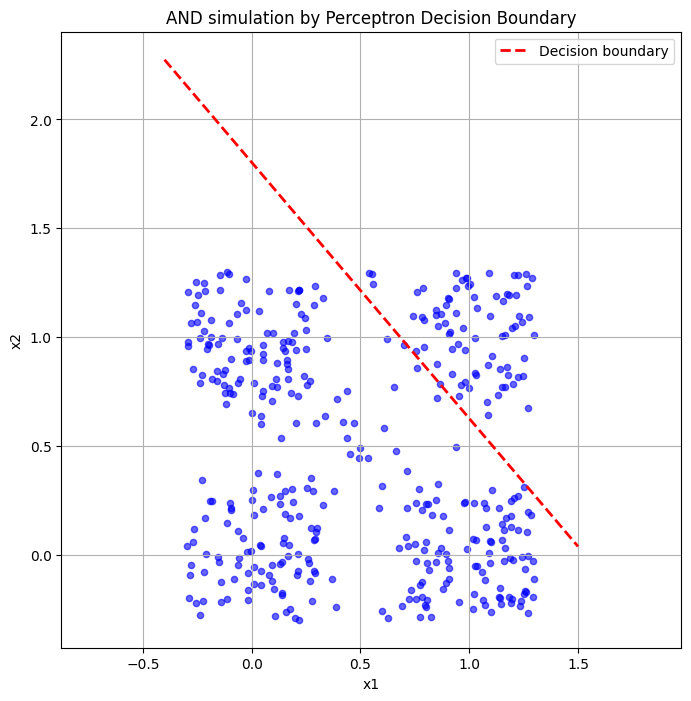

In [70]:
#畫點
plt.figure(figsize=(8, 8))
plt.scatter(
    points[:, 0], 
    points[:, 1],
    color="blue",
    s=20,
    alpha=0.6
    )

#畫線
x1_values = np.linspace(-0.4, 1.5, 100)

x2_values = -(
    w1 * x1_values + bias
) / w2

plt.plot(
    x1_values,
    x2_values,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Decision boundary"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("AND simulation by Perceptron Decision Boundary")
plt.xlim(points[:, 0].min() - 0.1, points[:, 0].max() + 0.1)
plt.ylim(points[:, 1].min() - 0.1, points[:, 1].max() + 0.1)
plt.grid(True)
plt.legend()
plt.axis("equal")  # x、y 軸比例相同，避免圖形被拉寬或壓扁
plt.show()

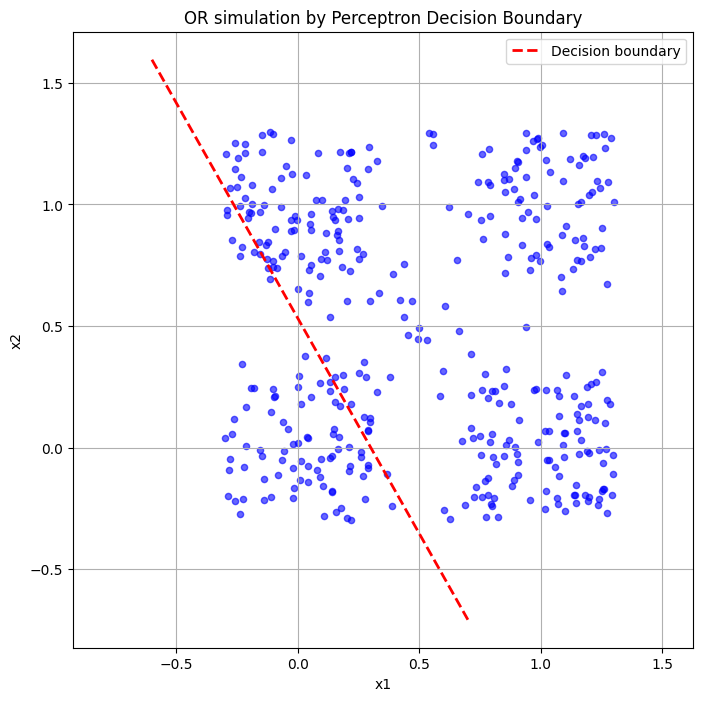

In [69]:
#畫點
plt.figure(figsize=(8, 8))
plt.scatter(
    points[:, 0], 
    points[:, 1],
    color="blue",
    s=20,
    alpha=0.6
    )

#畫線
x3_values = np.linspace(-0.6, 0.7, 100)

x4_values = -(
    w3 * x3_values + bias2
) / w4

plt.plot(
    x3_values,
    x4_values,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Decision boundary"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("OR simulation by Perceptron Decision Boundary")
plt.xlim(points[:, 0].min() - 0.1, points[:, 0].max() + 0.1)
plt.ylim(points[:, 1].min() - 0.1, points[:, 1].max() + 0.1)
plt.grid(True)
plt.legend()
plt.axis("equal")  # x、y 軸比例相同，避免圖形被拉寬或壓扁
plt.show()

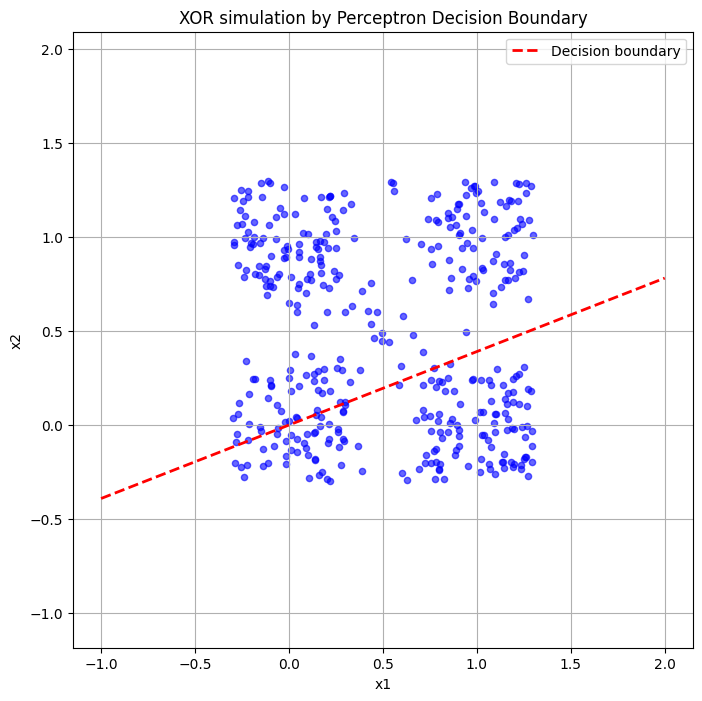

In [86]:
#畫點
plt.figure(figsize=(8, 8))
plt.scatter(
    points[:, 0], 
    points[:, 1],
    color="blue",
    s=20,
    alpha=0.6
    )

#畫線
x5_values = np.linspace(-1, 2, 100)

x6_values = -(
    w5 * x5_values + bias3
) / w6

plt.plot(
    x5_values,
    x6_values,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Decision boundary"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR simulation by Perceptron Decision Boundary")
plt.xlim(points[:, 0].min() - 0.1, points[:, 0].max() + 0.1)
plt.ylim(points[:, 1].min() - 0.1, points[:, 1].max() + 0.1)
plt.grid(True)
plt.legend()
plt.axis("equal")  # x、y 軸比例相同，避免圖形被拉寬或壓扁
plt.show()

Problem 2: Logistic Regression

⇒ Using scikit-learn, train a logistic regression classifier on the Iris dataset.

a) Report training and test accuracy.

b) Plot the sigmoid function and interpret the outputs as probabilities.

c) Compare logistic regression results with your perceptron

In [18]:
#讀取下載資料集
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris",output_dir ="E:\\HW\\1151\\ML\\Iris")

print("Path to dataset files:", path)

Iris_path="E:\\HW\\1151\\ML\\Iris\\Iris.csv"
file = open(Iris_path)
data = file.readlines()

Path to dataset files: E:\HW\1151\ML\Iris

In [19]:
#資料前處理
from rich import print
import random


rows = []

for line in data[1:]:
    row = line.strip().split(",")
    rows.append(row)

random.shuffle(rows)


data_float = []
for row in rows[:] :
    #去掉第0個element "Id"
    row_float = [float(x) for x in row[1:5]]
    data_float.append(row_float)


# train 為0~119 test為 120~150
train_set = data_float[:120]
test_set = data_float[120:]
train_labels = [ row[5] for row in rows[:120]]
test_labels = [ row[5] for row in rows[120:]]



In [20]:
#導入模型+設定
import sklearn

model = sklearn.linear_model.LogisticRegression()
#fit(X,y) X:input  y:Label


#把原本為str類的label 轉為 0 1 2 等int數字編號
test_labels = sklearn.preprocessing.LabelEncoder().fit_transform(test_labels)
train_labels = sklearn.preprocessing.LabelEncoder().fit_transform(train_labels)

In [22]:
# 訓練模型
model.fit(train_set, train_labels)


def test_model(model, data_set, label_set):
    predictions = model.predict(data_set)
    hit = 0

    for pred, true_label in zip(predictions, label_set):
        if pred == true_label:
            hit += 1
    #print("label:",label_set)
    #print("prediction:",predictions)
    return hit / len(predictions)

train_acc = test_model(model, train_set, train_labels)
test_acc = test_model(model, test_set, test_labels)

#print("train accuracy:", train_acc)
#print("test accuracy:", test_acc)

In [23]:
# 取得z值和 機率值
train_z = model.decision_function(train_set)
train_prob = model.predict_proba(train_set)


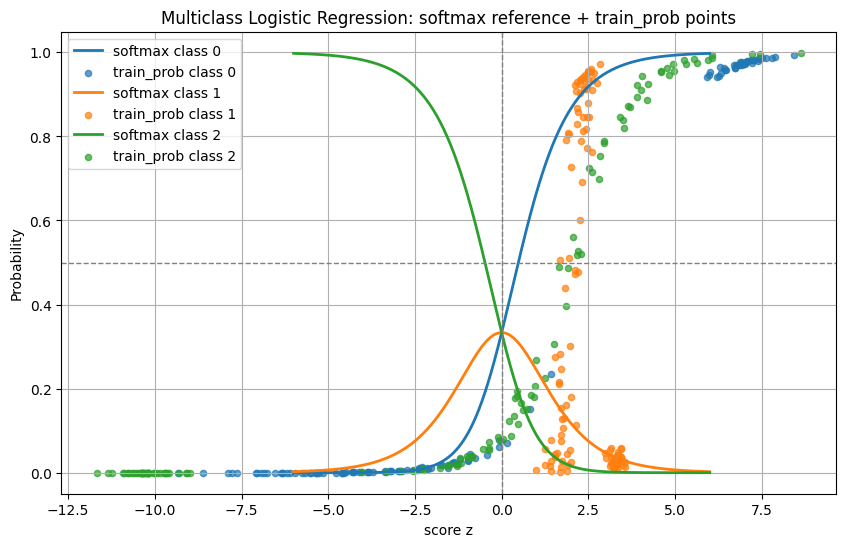

In [24]:
#畫圖
import numpy as np
import matplotlib.pyplot as plt

# 這裡用 softmax 當作多分類 logistic 的參考曲線
# 對每一個樣本，logistic 的 score vector z = [z0, z1, z2]
# softmax 機率為 p_i = exp(z_i) / sum_j exp(z_j)
# 這是 Iris 3 class 的正確機率定義，不能直接用單一 sigmoid

train_z = model.decision_function(train_set)
train_prob = model.predict_proba(train_set)

# 建立一個簡單的 softmax 參考曲線：
# 讓某一個 class 的分數 z_i 變化，其他兩個 class 固定為 0 和 -z_i
# 這樣可以看到 p_i 隨著分數增加時的趨勢
x_ref = np.linspace(-6, 6, 500)
other0 = np.zeros_like(x_ref)
other1 = -x_ref

scores = np.stack([x_ref, other0, other1], axis=1)
exp_scores = np.exp(scores)
softmax_ref = exp_scores / exp_scores.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i in range(3):
    plt.plot(
        x_ref,
        softmax_ref[:, i],
        color=colors[i],
        linewidth=2,
        label=f'softmax class {i}'
    )
    plt.scatter(
        train_z[:, i],
        train_prob[:, i],
        s=20,
        color=colors[i],
        alpha=0.7,
        label=f'train_prob class {i}'
    )

plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Multiclass Logistic Regression: softmax reference + train_prob points')
plt.xlabel('score z')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

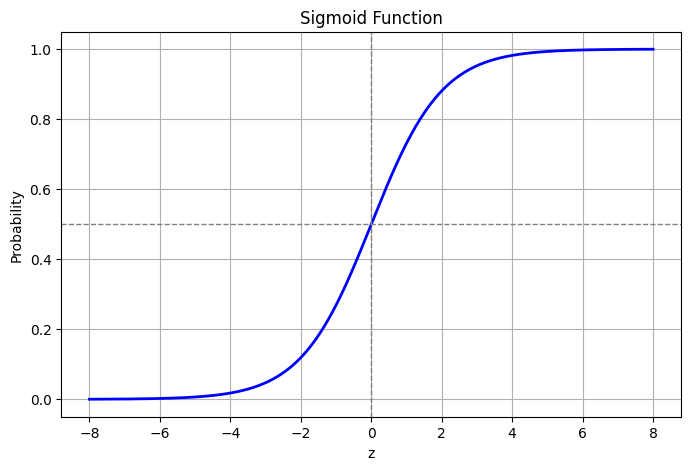

In [ ]:
#生成sgimoid圖
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 500)
p = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, p, color='blue', linewidth=2)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

Problem 3: k-Nearest Neighbors

⇒ Train a kNN classifier with k = 3,5,11 on the Iris dataset.

a) Compare decision boundaries and accuracy.

b) Discuss the effect of feature scaling.



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris",output_dir ="E:\\HW\\1151\\ML\\Iris")

print("Path to dataset files:", path)

Iris_path="E:\\HW\\1151\\ML\\Iris\\Iris.csv"
file = open(Iris_path)
data = file.readlines()

C:\Users\Hsiao Hui Chang\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: E:\HW\1151\ML\Iris


In [2]:
#資料前處理
from rich import print
import random


rows = []

for line in data[1:]:
    row = line.strip().split(",")
    rows.append(row)

random.shuffle(rows)


data_float = []
for row in rows[:] :
    #去掉第0個element "Id"
    row_float = [float(x) for x in row[1:5]]
    data_float.append(row_float)


# train 為0~119 test為 120~150
train_set = data_float[:120]
test_set = data_float[120:]
train_labels = [ row[5] for row in rows[:120]]
test_labels = [ row[5] for row in rows[120:]]

In [3]:
#導入模型+設定
import sklearn

model = sklearn.neighbors.KNeighborsClassifier
#fit(X,y) X:input  y:Label


#把原本為str類的label 轉為 0 1 2 等int數字編號
test_labels = sklearn.preprocessing.LabelEncoder().fit_transform(test_labels)
train_labels = sklearn.preprocessing.LabelEncoder().fit_transform(train_labels)

In [ ]:
#print(len(train_set))
#print(len(train_labels))

#print(train_set[:5])
#print(train_labels[:5])


120

120

[[4.8, 3.4, 1.6, 0.2], [5.8, 2.7, 3.9, 1.2], [6.4, 2.8, 5.6, 2.2], [6.7, 3.1, 4.4, 1.4], [5.0, 3.2, 1.2, 0.2]]

[0 1 2 1 0]

In [4]:
#模型訓練

for k in[3, 5, 11]:
    knn = model(n_neighbors = k)
    knn.fit(train_set,train_labels)
    
    y_pred = knn.predict(test_set)
    acc = sklearn.metrics.accuracy_score(test_labels, y_pred)
    print(f"k={k}, test accuracy = {acc:.4f}")




k=3, test accuracy = 0.9667

k=5, test accuracy = 1.0000

k=11, test accuracy = 1.0000

k=3, test accuracy = 0.9333

k=5, test accuracy = 0.9333

k=11, test accuracy = 0.9667

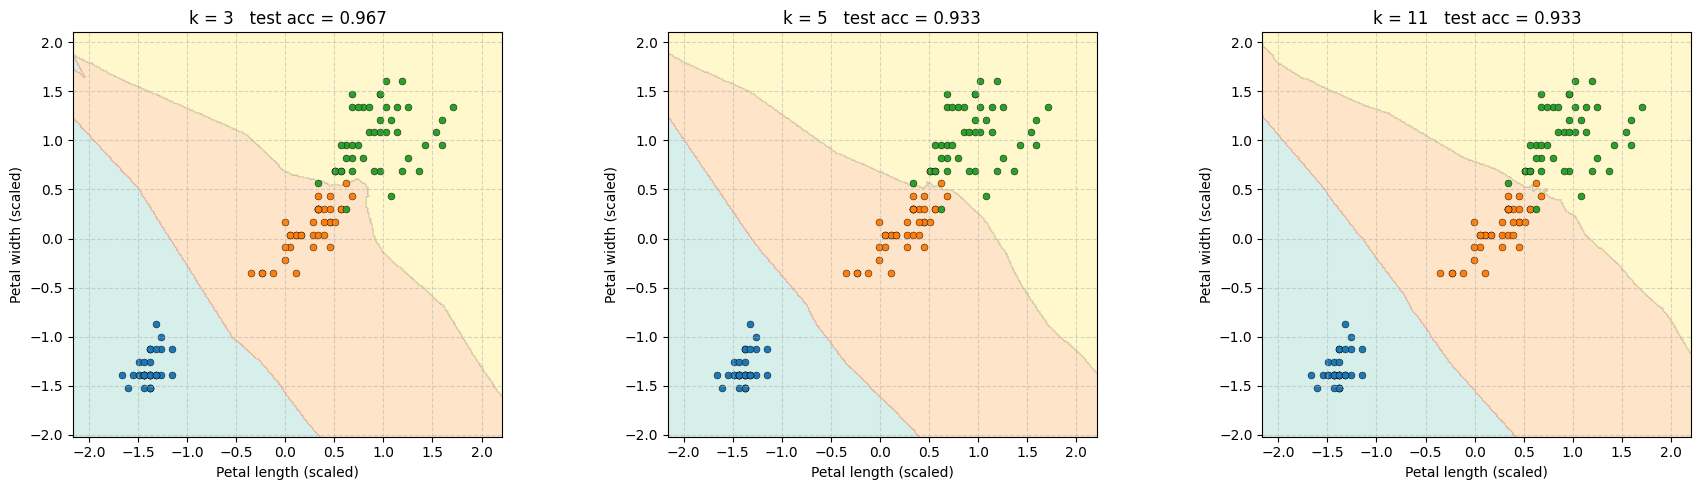

In [6]:
# kNN with 4 features + Standardization
# 這裡使用 Iris 的所有 4 個特徵：
# Sepal Length, Sepal Width, Petal Length, Petal Width
# 這樣比較符合原始資料的完整資訊，並且更像真實的分類任務。

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 先將資料轉成 numpy array
X_train = np.array(train_set, dtype=float)
X_test = np.array(test_set, dtype=float)
y_train = np.array(train_labels)
y_test = np.array(test_labels)

# StandardScaler：把每個特徵標準化到平均 0、標準差 1
# kNN 是依賴距離的模型，所以需要標準化，否則數值大的特徵會主導分類。
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 先看 4 features 的 accuracy（不做圖）
for k in [3, 5, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"k={k}, test accuracy = {acc:.4f}")

# 下面這段是 2D 視覺化：
# 只使用花瓣長度 + 花瓣寬度來畫決策邊界，便於觀察「邊界的平滑程度」
# 其實在 kNN 中，當使用 4 個 features 時，決策邊界並不是一條 2D 線，
# 而是一個更高維的分割面；所以我們用 2D 子空間來視覺化比較直觀。
X2_train = X_train_scaled[:, [2, 3]]
X2_test = X_test_scaled[:, [2, 3]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, [3, 5, 11]):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X2_train, y_train)

    y_pred = knn.predict(X2_test)
    acc = accuracy_score(y_test, y_pred)

    # 建立網格，模擬整個 2D 空間的分類結果
    x_min, x_max = X2_train[:, 0].min() - 0.5, X2_train[:, 0].max() + 0.5
    y_min, y_max = X2_train[:, 1].min() - 0.5, X2_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = knn.predict(grid).reshape(xx.shape)

    # 以不同顏色區分分類區域
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='Set3')

    # 畫出訓練資料點
    for cls in range(3):
        mask = y_train == cls
        ax.scatter(
            X2_train[mask, 0], X2_train[mask, 1],
            s=25,
            edgecolors='k',
            linewidth=0.3,
            label=f'class {cls}'
        )

    ax.set_title(f'k = {k}   test acc = {acc:.3f}')
    ax.set_xlabel('Petal length (scaled)')
    ax.set_ylabel('Petal width (scaled)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


Problem 4: Support Vector Machines

⇒ Train an SVM with linear kernel and with RBF kernel.

a) Compare performance.

b) Discuss: When might an SVM outperform logistic regression or kNN?

1



In [8]:
import kagglehub
import sklearn

# Download latest version
path = kagglehub.dataset_download("uciml/iris",output_dir ="E:\\HW\\1151\\ML\\Iris")

print("Path to dataset files:", path)

Iris_path="E:\\HW\\1151\\ML\\Iris\\Iris.csv"
file = open(Iris_path)
data = file.readlines()

Path to dataset files: E:\HW\1151\ML\Iris

In [11]:
#資料前處理
from rich import print
import random


rows = []

for line in data[1:]:
    row = line.strip().split(",")
    rows.append(row)

random.shuffle(rows)


data_float = []
for row in rows[:] :
    #去掉第0個element "Id"
    row_float = [float(x) for x in row[1:5]]
    data_float.append(row_float)


# train 為0~119 test為 120~150
train_set = data_float[:120]
test_set = data_float[120:]
train_labels = [ row[5] for row in rows[:120]]
test_labels = [ row[5] for row in rows[120:]]



#把原本為str類的label 轉為 0 1 2 等int數字編號
test_labels = sklearn.preprocessing.LabelEncoder().fit_transform(test_labels)
train_labels = sklearn.preprocessing.LabelEncoder().fit_transform(train_labels)

# standardization data
scaler = sklearn.preprocessing.StandardScaler()
train_scaled = scaler.fit_transform(train_set)
test_scaled = scaler.transform(test_set)

In [12]:
# Train SVMs using the same scaled features
linear_svm = sklearn.svm.SVC(kernel="linear", C=1.0)
rbf_svm = sklearn.svm.SVC(kernel="rbf", C=1.0, gamma="scale")

# Fit on the scaled training data
linear_svm.fit(train_scaled, train_labels)
rbf_svm.fit(train_scaled, train_labels)

# Predict on the scaled test data
y_pred_linear = linear_svm.predict(test_scaled)
y_pred_rbf = rbf_svm.predict(test_scaled)

# Evaluate
print("=== Linear SVM ===")
print("Accuracy:", sklearn.metrics.accuracy_score(test_labels, y_pred_linear))
print(sklearn.metrics.classification_report(test_labels, y_pred_linear))

print("=== RBF SVM ===")
print("Accuracy:", sklearn.metrics.accuracy_score(test_labels, y_pred_rbf))
print(sklearn.metrics.classification_report(test_labels, y_pred_rbf))



=== Linear SVM ===

Accuracy: 0.9666666666666667

precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.92      1.00      0.96        11
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

=== RBF SVM ===

Accuracy: 0.9666666666666667

precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.92      1.00      0.96        11
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Problem 5: Decision Trees and Ensembles

⇒ Train a decision tree with varying depths.

a) Compare results with Random Forest and Gradient Boosting.

b) Discuss bias-variance trade-off in these models.



In [21]:
import kagglehub
import sklearn

# Download latest version
path = kagglehub.dataset_download("uciml/iris",output_dir ="E:\\HW\\1151\\ML\\Iris")

print("Path to dataset files:", path)

Iris_path="E:\\HW\\1151\\ML\\Iris\\Iris.csv"
file = open(Iris_path)
data = file.readlines()

#資料前處理
from rich import print
import random


rows = []

for line in data[1:]:
    row = line.strip().split(",")
    rows.append(row)
#
random.seed(17)
random.shuffle(rows)


data_float = []
for row in rows[:] :
    #去掉第0個element "Id"
    row_float = [float(x) for x in row[1:5]]
    data_float.append(row_float)


# train 為0~119 test為 120~150
X_train = data_float[:120]
X_test = data_float[120:]
train_labels = [ row[5] for row in rows[:120]]
test_labels = [ row[5] for row in rows[120:]]



#把原本為str類的label 轉為 0 1 2 等int數字編號
y_test = sklearn.preprocessing.LabelEncoder().fit_transform(test_labels)
y_train = sklearn.preprocessing.LabelEncoder().fit_transform(train_labels)



Path to dataset files: E:\HW\1151\ML\Iris

Decision Tree results:

max_depth  train_accuracy  test_accuracy
         1        0.683333            0.6
         2        0.975000            0.9
         3        0.983333            0.9
         4        0.991667            0.9
         5        1.000000            0.9
         6        1.000000            0.9
         7        1.000000            0.9
         8        1.000000            0.9
         9        1.000000            0.9
        10        1.000000            0.9
        11        1.000000            0.9
        12        1.000000            0.9
        13        1.000000            0.9
        14        1.000000            0.9
        15        1.000000            0.9

Best Decision Tree depth: 2

Model comparison:

model  train_accuracy  test_accuracy
Decision Tree (best depth)           1.000       0.900000
             Random Forest           0.975       0.900000
         Gradient Boosting           1.000       0.933333

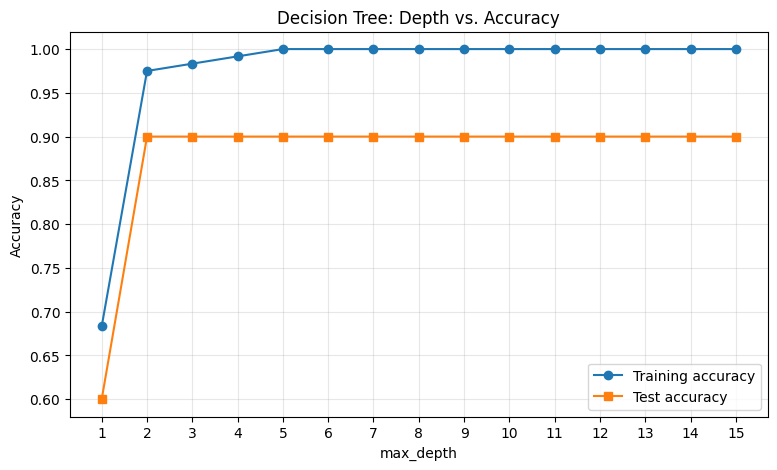

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score



# 3. Train Decision Trees with varying depths
depths = range(1, 16)

tree_train_scores = []
tree_test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    tree_train_scores.append(train_acc)
    tree_test_scores.append(test_acc)

# 4. Print Decision Tree results
results_tree = pd.DataFrame({
    "max_depth": list(depths),
    "train_accuracy": tree_train_scores,
    "test_accuracy": tree_test_scores
})

print("Decision Tree results:")
print(results_tree.to_string(index=False))

# 5. Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))

# 6. Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

gb_train_acc = accuracy_score(y_train, gb.predict(X_train))
gb_test_acc = accuracy_score(y_test, gb.predict(X_test))

# 7. Compare models
comparison = pd.DataFrame({
    "model": ["Decision Tree (best depth)", "Random Forest", "Gradient Boosting"],
    "train_accuracy": [
        max(tree_train_scores),
        rf_train_acc,
        gb_train_acc
    ],
    "test_accuracy": [
        max(tree_test_scores),
        rf_test_acc,
        gb_test_acc
    ]
})

best_depth = list(depths)[np.argmax(tree_test_scores)]

print("\nBest Decision Tree depth:", best_depth)
print("\nModel comparison:")
print(comparison.to_string(index=False))

# 8. Plot tree depth vs. accuracy
plt.figure(figsize=(9, 5))
plt.plot(depths, tree_train_scores, marker="o", label="Training accuracy")
plt.plot(depths, tree_test_scores, marker="s", label="Test accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Depth vs. Accuracy")
plt.xticks(list(depths))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Problem 6: Reflection

a) Which classifier performed best on your chosen dataset?

b) Which was easiest to interpret?

c) How would you decide which classifier to use in a real project?

⇒ Suggested reading for Ph.D students: book1, Exercises in Chapter 2 and 3 about probability.

## Problem 4: Support Vector Machines

⇒ Train an SVM with linear kernel and with RBF kernel.

### a) Compare performance

We compare the accuracy and decision boundary behavior of the two kernel choices on the Iris dataset.

### b) Discussion

An SVM may outperform logistic regression or kNN when the class boundary is well separated and the data may benefit from a large-margin classifier. The RBF kernel is especially useful when the classes are not linearly separable in the original feature space, while a linear SVM is a strong baseline when the decision boundary is close to linear. SVMs also perform well in moderate-sized datasets with clear margins, especially when the feature dimensionality is not too extreme and the data are well scaled.

Compared with logistic regression, SVMs focus on margin maximization rather than probability estimation, which can give better generalization when the classes are cleanly separated. Compared with kNN, SVMs are more robust to local density fluctuations and do not rely on a distance metric over all training samples, so they can be more stable when there are many irrelevant features or when the class structure is global rather than local.
